# <font color='white'>1. Read Libraries<font>

In [1]:
import pandas as pd
import numpy as np
import warnings
# from sklearn.metrics import roc_auc_score, log_loss, precision_recall_fscore_support, confusion_matrix
import lightgbm as lgb


pd.set_option('display.max_columns',None)
# pd.set_option('display.max_rows', None)

# <font color='white'>2. Functions<font>

## <font color='pink'>Feature Engineering<font>

In [ ]:
def chatgpt_feature_engineering(df_):
    df = df_.copy()

    # -------------------------------------------------------------------
    # # Zaman ile ilgili sütunların datetime'a çevrilmesi
    df['week_start'] = pd.to_datetime(df['week_start'])
    df['customer_created_at'] = pd.to_datetime(df['customer_created_at'])

    # -------------------------------------------------------------------
    # Haftaya göre tarih sıralaması yapılması
    df = df.sort_values(
        ['customer_id', 'product_unit_variant_id', 'week_start']
    ).reset_index(drop=True)

    # -------------------------------------------------------------------
    # İlgili haftadaki hafta, ay, yıl featurelarının ayrı sütunlara dağıtılması
    df['week'] = df['week_start'].dt.isocalendar().week.astype(int)
    df['month'] = df['week_start'].dt.month.astype(int)
    df['year'] = df['week_start'].dt.year.astype(int)

    # -------------------------------------------------------------------
    # # customer age: müşteri ne kadar zamandır platformda
    df['cust_age_days'] = (
        (df['week_start'] - df['customer_created_at'])
        .dt.days.clip(lower=0)
        .fillna(0)
        .astype(int)
    )

    # -------------------------------------------------------------------
    # 
    for col in ['purchased_this_week', 'qty_this_week', 'num_orders_week']: 
        if col not in df.columns:
            df[col] = 0 # Test setinde yok, bu yüzden ekliyoruz. 
        else:
            df[col] = df[col].fillna(0) # Trainde Null ise 0 yap diyoruz.

    # -------------------------------------------------------------------
    # Group
    grp = df.groupby(['customer_id', 'product_unit_variant_id'])

    # -------------------------------------------------------------------
    # Lag features (PAST ONLY)
    df['purchased_lag_1'] = grp['purchased_this_week'].shift(1).fillna(0).astype(int)
    df['purchased_lag_2'] = grp['purchased_this_week'].shift(2).fillna(0).astype(int)
    df['purchased_lag_3'] = grp['purchased_this_week'].shift(3).fillna(0).astype(int)

    # -------------------------------------------------------------------
    # Rolling past purchase count (exclude current)
    roll_purch_4 = (
        grp['purchased_this_week']
        .rolling(4, min_periods=1)
        .sum()
        .reset_index(level=[0,1], drop=True)
    )

    df['roll_purchased_4_past'] = (
        roll_purch_4 - df['purchased_this_week']
    ).clip(lower=0)

    # -------------------------------------------------------------------
    # Rolling past quantity
    roll_qty_4 = (
        grp['qty_this_week']
        .rolling(4, min_periods=1)
        .sum()
        .reset_index(level=[0,1], drop=True)
    )

    df['roll_quantity_4_past'] = (
        roll_qty_4 - df['qty_this_week']
    ).clip(lower=0)

    # -------------------------------------------------------------------
    # Cumulative until last week
    df['customer_purch_until_last_week'] = (
        grp['purchased_this_week']
        .cumsum()
        .shift(1)
        .fillna(0)
    )

    df['customer_quantity_until_last_week'] = (
        grp['qty_this_week']
        .cumsum()
        .shift(1)
        .fillna(0)
    )

    # -------------------------------------------------------------------
    # Purchased with other products (PAST)
    df['purchased_with_other_products'] = (
        (df['purchased_this_week'] == 1) &
        (df['num_orders_week'] > 1)
    ).astype(int)

    df['purchased_with_others_last_week'] = (
        grp['purchased_with_other_products']
        .shift(1)
        .fillna(0)
        .astype(int)
    )

    return df


In [22]:
def feature_engineering(df_):
    df = df_.copy()

    # Zaman ile ilgili sütunların datetime'a çevrilmesi

    df['week_start'] = pd.to_datetime(df['week_start'])
        
    df['customer_created_at'] = pd.to_datetime(df['customer_created_at'])

    # -----------------------------------------------------------------------
    # Haftaya göre tarih sıralaması yapılması
    df = df.sort_values(['customer_id','product_unit_variant_id','week_start']).reset_index(drop=True)

    # -----------------------------------------------------------------------
    # İlgili haftadaki hafta, ay, yıl featurelarının ayrı sütunlara dağıtılması
    df['week'] = df['week_start'].dt.isocalendar().week.astype(int)
    df['month'] = df['week_start'].dt.month.astype(int)
    df['year'] = df['week_start'].dt.year.astype(int)

    # -----------------------------------------------------------------------
    # customer age: müşteri ne kadar zamandır platformda
    df['cust_age_days'] = (df['week_start'] - df['customer_created_at']).dt.days.clip(lower=0).fillna(0).astype(int)

    # -----------------------------------------------------------------------
    # Müşteri bir önceki hafta alışveriş yaptı mı? İki önceki hafta, üç önceki hafta alışveriş yaptı mı? 
    # Ayrı sütunlarda bunu gösteriyoruz.
    # -----------------------------------------------------------------------

    # Müşteri + ürün varyantı bazında grupluyoruz ve grubun içindeki purchased_this_week sütununu seçiyoruz.

    # Test setinde purchased_this_week NaN gelecek. 
    # Biz önceki haftalara bakarken bu sütunun bilgisiyle ilgilenmiyoruz zaten.
    df['purchased_this_week'] = df['purchased_this_week'].fillna(0)

    group_purchased = df.groupby(['customer_id','product_unit_variant_id'])['purchased_this_week']

    # önceki hafta alışveriş yaptı mı?
    # aynı müşteri & aynı ürün için bir önceki satır (bir önceki haftayı) getirir.
    # Eğer önceki hafta yoksa → NaN

    df['purchased_lag_1'] = group_purchased.shift(1).fillna(0).astype(int)
    df['purchased_lag_2'] = group_purchased.shift(2).fillna(0).astype(int)
    df['purchased_lag_3'] = group_purchased.shift(3).fillna(0).astype(int)

    # -----------------------------------------------
    # Son 4 haftada kaç kez satın alınmış?
    # -----------------------------------------------

    # group_purchased = df.groupby(['customer_id','product_unit_variant_id'])['purchased_this_week']

    roll_purchased = group_purchased.rolling(4, min_periods=1).sum().reset_index(level=[0,1], drop=True)

    # içinde bulunulan haftayı da içeren
    df['roll_purchased_4_including_current'] = roll_purchased.fillna(0)

    # içinde bulunulan haftayı içermeyen
    df['roll_purchased_4_past'] = (df['roll_purchased_4_including_current'] - df['purchased_this_week']).clip(lower=0)

    # -----------------------------------------------
    # Son 4 haftada kaç adet satın alınmış?
    # -----------------------------------------------
    grp_quantity = df.groupby(['customer_id','product_unit_variant_id'])['qty_this_week']

    roll_quantity = grp_quantity.rolling(4, min_periods=1).sum().reset_index(level=[0,1], drop=True)

    # içinde bulunulan haftayı da içeren
    df['roll_quantity_4_including_current'] = roll_quantity.fillna(0)

    # içinde bulunulan haftayı içermeyen
    df['roll_quantity_4_past'] = (df['roll_quantity_4_including_current'] - df['qty_this_week']).clip(lower=0)

    # -----------------------------------------------
    # Müşteri geçen haftaya kadar bu üründen kaç kez satın alım yapmış?
    # -----------------------------------------------

    df['customer_purch_until_last_week'] = (
        df.groupby(['customer_id', 'product_unit_variant_id'])['purchased_this_week']
        .cumsum()
        .shift(1)
        .fillna(0)
    )

    # -----------------------------------------------
    # Müşteri geçen haftaya kadar bu üründen kaç adet satın alım yapmış?
    # -----------------------------------------------

    df['customer_quantity_until_last_week'] = (
        df.groupby(['customer_id', 'product_unit_variant_id'])['qty_this_week']
        .cumsum()
        .shift(1)
        .fillna(0)
    )

    # -----------------------------------------------
    # Geçen hafta bu ürünü diğer ürünlerle birlikte mi aldı?
    # -----------------------------------------------
    # Bu ürünü diğer siparişlerle birlikte almışsa 1, kendisi tek başına bu ürünü almışsa 0.
    # num_orders_week: bu satırdaki ürünü de içeren "ayrı" siparişlerin sayısını ifade ediyor.

    df['purchased_with_other_products'] = (
        (df['purchased_this_week'] == 1) & (df['num_orders_week'] > 1)
    ).astype(int)

    # Şimdi bunu 1 hafta geriye kaydırıyoruz
    df['purchased_with_others_last_week'] = (
        df.groupby(['customer_id','product_unit_variant_id'])['purchased_with_other_products']
        .shift(1)
        .fillna(0)
        .astype(int)
    )


    return df


## <font color='pink'>Models<font>

In [19]:
def model_lightgbm(df_, features, target_col,
                           val_weeks=4, test_weeks=4,
                           params=None, num_boost_round=1000,
                           early_stopping_rounds=50, verbose=False,
                           categorical_features=None):


    df = df_.copy()
    # ---------------------------------------------------------------------------
    # 1. LightGBM kategorik değişkenleri işleyebilsin diye category tipine çeviriyorum. 

    for col in categorical_features:
        df[col] = df[col].astype('category')

    # ---------------------------------------------------------------------------
    # 2. Train-validation-test ayrımı yapıyorum.
    df = df.copy().sort_values('week_start')
    unique_weeks = np.sort(df['week_start'].unique())

    test_cutoff = unique_weeks[-test_weeks] # sondan 4. haftanın tarihi
    val_cutoff = unique_weeks[-(test_weeks + val_weeks)] # sondan 8. haftanın tarihi

    train_mask = df['week_start'] < val_cutoff # True False dönüyor
    val_mask = (df['week_start'] >= val_cutoff) & (df['week_start'] < test_cutoff)
    test_mask = df['week_start'] >= test_cutoff

    X_train = df.loc[train_mask, features]
    y_train = df.loc[train_mask, target_col]
    X_val = df.loc[val_mask, features]
    y_val = df.loc[val_mask, target_col]
    X_test = df.loc[test_mask, features]
    y_test = df.loc[test_mask, target_col]

    # Train ve Validation dataframe'lerinin oluşturulması
    # LightGBM pandas.DataFrame ile değil,lgb.Dataset ile daha hızlı çalışıyormuş o yüzden bu şekilde oluşturuyoruz. 
    lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features, free_raw_data=False)
    lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train, categorical_feature=categorical_features, free_raw_data=False)


    # default params
    if params is None:
        params = {
            'objective': 'binary',
            'metric': 'binary_logloss',
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'learning_rate': 0.05,
            'num_leaves': 63,
            'seed': 42,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.8,
            'bagging_freq': 5
        }

    # Add early stopping into params
    # Validationdaki en iyi skoru bulmaya çalışıyor, early_stopping_rounds kadar iterasyon dönüyor, durduğu yer best_iteration oluyor.
    params['early_stopping_round'] = early_stopping_rounds

    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=num_boost_round, 
        valid_sets=[lgb_train, lgb_val],
        valid_names=['train', 'val']
    )

    # preds
    preds_val = model.predict(X_val, num_iteration=model.best_iteration)
    preds_test = model.predict(X_test, num_iteration=model.best_iteration)


    return preds_val, preds_test, y_val, y_test, model,model.best_iteration,params


In [20]:
def model_lightgbm_final(
    df_,
    df_test,
    features,
    target_col,
    categorical_features,
    params,
    best_iteration
):
    df_train = df_.copy()
    df_test = df_test.copy()

    # categorical cast
    for col in categorical_features:
        df_train[col] = df_train[col].astype('category')
        df_test[col] = df_test[col].astype('category')

    X_train = df_train[features]
    y_train = df_train[target_col]

    X_test = df_test[features]

    lgb_train = lgb.Dataset(
        X_train,
        label=y_train,
        categorical_feature=categorical_features
    )

    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=best_iteration
    )

    test_preds = model.predict(X_test)

    return test_preds, model


## <font color='pink'>Metrics<font>

In [5]:
from sklearn import metrics

from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def compute_metrics(y_true,preds,threshold,plot_cm=True):
        out = {}

        out['auc'] = float(roc_auc_score(y_true, preds))
        out['logloss'] = float(log_loss(y_true, preds, labels=[0,1])) # labels: bu problemde mümkün olan sınıflar bunlar

        # binary predictions at 0.5
        y_pred_bin = (preds >= threshold).astype(int)

        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred_bin, average='binary', zero_division=0)

        out.update({'precision': float(p), 'recall': float(r), 'f1': float(f1)})
        # out['confusion_matrix'] = confusion_matrix(y_true, y_pred_bin).tolist()

        cm = confusion_matrix(y_true, y_pred_bin)
        out['confusion_matrix'] = cm.tolist()

        if plot_cm:
            disp = metrics.ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=[0, 1]
            )
            disp.plot()
            plt.title(f'Confusion Matrix (threshold={threshold})')
            plt.show()


        return out



In [21]:
df_raw.columns

NameError: name 'df_raw' is not defined

In [6]:
def compare_val_test_scores(metrics_val,metrics_test):

    df_comparison = pd.DataFrame({
        'metric': ['auc', 'logloss', 'precision', 'recall', 'f1'],
        'validation': [
            metrics_val['auc'],
            metrics_val['logloss'],
            metrics_val['precision'],
            metrics_val['recall'],
            metrics_val['f1']
        ],
        'test': [
            metrics_test['auc'],
            metrics_test['logloss'],
            metrics_test['precision'],
            metrics_test['recall'],
            metrics_test['f1']
        ]
    })

    df_comparison['diff_test_minus_val'] = df_comparison['test'] - df_comparison['validation']

    return df_comparison

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def plot_val_test_scores(metrics_val,metrics_test):

    metrics = ['auc', 'logloss', 'precision', 'recall', 'f1']
    val_scores = [metrics_val[m] for m in metrics]
    test_scores = [metrics_test[m] for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(10,5))
    plt.bar(x - width/2, val_scores, width, label='Validation')
    plt.bar(x + width/2, test_scores, width, label='Test')

    plt.xticks(x, metrics)
    plt.ylabel('Score')
    plt.title('Validation vs Test Metrics Comparison')
    plt.legend()
    plt.tight_layout()
    plt.show()

# <font color='white'>3. Running Functions<font>

## <font color='pink'>1. Data Read<font>

In [22]:
# 1. Data Read

df = pd.read_csv("../data/train.csv")

df_test = pd.read_csv("../data/test.csv")

In [24]:
df_test.columns

Index(['ID', 'customer_id', 'product_unit_variant_id', 'week_start',
       'product_id', 'grade_name', 'unit_name', 'product_grade_variant_id',
       'customer_category', 'customer_status', 'customer_created_at'],
      dtype='object')

-----

## <font color='pink'>2. Model<font>

In [4]:
df_test.columns

Index(['ID', 'customer_id', 'product_unit_variant_id', 'week_start',
       'product_id', 'grade_name', 'unit_name', 'product_grade_variant_id',
       'customer_category', 'customer_status', 'customer_created_at'],
      dtype='object')

In [7]:
df['week_start'].unique()

array(['2024-10-28', '2024-11-04', '2024-11-11', '2024-11-18',
       '2024-11-25', '2024-12-02', '2024-12-09', '2024-12-16',
       '2024-12-23', '2024-12-30', '2025-01-06', '2025-01-13',
       '2025-01-20', '2025-01-27', '2025-02-03', '2025-02-10',
       '2025-02-17', '2025-02-24', '2025-03-03', '2025-03-10',
       '2025-03-17', '2025-03-24', '2025-03-31', '2025-04-07',
       '2025-04-14', '2025-04-21', '2025-04-28', '2025-05-05',
       '2025-05-12', '2025-05-19', '2025-05-26', '2025-06-02',
       '2025-06-09', '2025-06-16', '2025-06-23', '2025-06-30',
       '2025-07-07', '2025-07-14', '2025-07-21', '2025-07-28',
       '2025-08-04', '2025-08-11', '2025-08-18', '2025-08-25',
       '2025-09-01', '2025-09-08'], dtype=object)

In [5]:
df_test['week_start'].unique()

array(['2025-09-22', '2025-09-29', '2025-10-06', '2025-10-13',
       '2025-10-20', '2025-10-27'], dtype=object)

In [26]:
df.columns

Index(['ID', 'customer_id', 'product_unit_variant_id', 'week_start',
       'qty_this_week', 'num_orders_week', 'spend_this_week',
       'purchased_this_week', 'product_id', 'grade_name', 'unit_name',
       'product_grade_variant_id', 'selling_price', 'customer_category',
       'customer_status', 'customer_created_at', 'Target_qty_next_1w',
       'Target_purchase_next_1w', 'Target_qty_next_2w',
       'Target_purchase_next_2w'],
      dtype='object')

In [48]:
df_test[(df_test['customer_id'] == 416) & (df_test['product_unit_variant_id'] == 104) ][['ID','customer_id','product_unit_variant_id','week_start']]

,ID,customer_id,product_unit_variant_id,week_start
10381,416_104_20250922,416,104,2025-09-22
83109,416_104_20250929,416,104,2025-09-29
102440,416_104_20251006,416,104,2025-10-06
159169,416_104_20251013,416,104,2025-10-13
217493,416_104_20251020,416,104,2025-10-20
252934,416_104_20251027,416,104,2025-10-27


In [43]:
df[(df['customer_id'] == 416) & (df['product_unit_variant_id'] == 104) ][['ID','customer_id','product_unit_variant_id','week_start','qty_this_week','purchased_this_week','Target_qty_next_1w',
       'Target_purchase_next_1w', 'Target_qty_next_2w',
       'Target_purchase_next_2w']].reset_index(drop=True).tail(20)

,ID,customer_id,product_unit_variant_id,week_start,qty_this_week,purchased_this_week,Target_qty_next_1w,Target_purchase_next_1w,Target_qty_next_2w,Target_purchase_next_2w
26,416_104_20250428,416,104,2025-04-28,0.0,0,0.0,0,0.0,0
27,416_104_20250505,416,104,2025-05-05,0.0,0,0.0,0,0.0,0
28,416_104_20250512,416,104,2025-05-12,0.0,0,0.0,0,0.0,0
29,416_104_20250519,416,104,2025-05-19,0.0,0,0.0,0,0.0,0
30,416_104_20250526,416,104,2025-05-26,0.0,0,0.0,0,8.0,1
31,416_104_20250602,416,104,2025-06-02,0.0,0,8.0,1,16.0,1
32,416_104_20250609,416,104,2025-06-09,8.0,1,8.0,1,16.0,1
33,416_104_20250616,416,104,2025-06-16,8.0,1,8.0,1,21.0,1
34,416_104_20250623,416,104,2025-06-23,8.0,1,13.0,1,29.0,1
35,416_104_20250630,416,104,2025-06-30,13.0,1,16.0,1,26.0,1


In [ ]:
df[['ID','Target_qty_next_1w',
       'Target_purchase_next_1w', 'Target_qty_next_2w',
       'Target_purchase_next_2w']]

In [37]:
df.tail(50)

,ID,customer_id,product_unit_variant_id,week_start,qty_this_week,num_orders_week,spend_this_week,purchased_this_week,product_id,grade_name,unit_name,product_grade_variant_id,selling_price,customer_category,customer_status,customer_created_at,Target_qty_next_1w,Target_purchase_next_1w,Target_qty_next_2w,Target_purchase_next_2w
2114386,719_585_20250908,719,585,2025-09-08,0.0,0.0,0.0,0,493,GRADE_05,UNIT_001,547,2017.24,CUST_CAT_003,CUST_STAT_000,2025-08-27,0.0,0,0.0,0
2114387,701_78_20250908,701,78,2025-09-08,0.0,0.0,0.0,0,143,GRADE_01,UNIT_007,187,47.00,CUST_CAT_003,CUST_STAT_000,2025-08-11,0.0,0,0.0,0
2114388,403_446_20250908,403,446,2025-09-08,0.0,0.0,0.0,0,383,GRADE_05,UNIT_006,429,370.00,CUST_CAT_006,CUST_STAT_000,2024-10-16,0.0,0,0.0,0
2114389,508_293_20250908,508,293,2025-09-08,0.0,0.0,0.0,0,234,GRADE_01,UNIT_004,261,80.00,CUST_CAT_003,CUST_STAT_000,2024-04-29,0.0,0,0.0,0
2114390,416_104_20250908,416,104,2025-09-08,11.0,2.0,96779.5,1,49,GRADE_01,UNIT_008,63,190.00,CUST_CAT_003,CUST_STAT_000,2024-10-14,7.0,1,15.0,1
2114391,426_437_20250908,426,437,2025-09-08,0.0,0.0,0.0,0,374,GRADE_05,UNIT_006,420,225.00,CUST_CAT_005,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
2114392,719_82_20250908,719,82,2025-09-08,0.0,0.0,0.0,0,35,GRADE_01,UNIT_008,49,118.00,CUST_CAT_003,CUST_STAT_000,2025-08-27,0.0,0,0.0,0
2114393,691_420_20250908,691,420,2025-09-08,0.0,0.0,0.0,0,358,GRADE_05,UNIT_006,404,203.00,CUST_CAT_003,CUST_STAT_000,2025-07-30,0.0,0,0.0,0
2114394,578_35_20250908,578,35,2025-09-08,0.0,0.0,0.0,0,5,GRADE_01,UNIT_008,7,145.00,CUST_CAT_003,CUST_STAT_000,2025-04-03,0.0,0,0.0,0
2114395,623_436_20250908,623,436,2025-09-08,0.0,0.0,0.0,0,373,GRADE_05,UNIT_006,419,455.00,CUST_CAT_003,CUST_STAT_000,2025-05-15,0.0,0,0.0,0


In [19]:
df_test[df_test['product_unit_variant_id'] == 498]['week_start'].unique()

array(['2025-09-22', '2025-09-29', '2025-10-06', '2025-10-13',
       '2025-10-20', '2025-10-27'], dtype=object)

In [14]:
df[df['product_unit_variant_id']] = 278]

SyntaxError: unmatched ']' (1190178545.py, line 1)

In [9]:
df['week_start'].unique()

array(['2024-10-28', '2024-11-04', '2024-11-11', '2024-11-18',
       '2024-11-25', '2024-12-02', '2024-12-09', '2024-12-16',
       '2024-12-23', '2024-12-30', '2025-01-06', '2025-01-13',
       '2025-01-20', '2025-01-27', '2025-02-03', '2025-02-10',
       '2025-02-17', '2025-02-24', '2025-03-03', '2025-03-10',
       '2025-03-17', '2025-03-24', '2025-03-31', '2025-04-07',
       '2025-04-14', '2025-04-21', '2025-04-28', '2025-05-05',
       '2025-05-12', '2025-05-19', '2025-05-26', '2025-06-02',
       '2025-06-09', '2025-06-16', '2025-06-23', '2025-06-30',
       '2025-07-07', '2025-07-14', '2025-07-21', '2025-07-28',
       '2025-08-04', '2025-08-11', '2025-08-18', '2025-08-25',
       '2025-09-01', '2025-09-08'], dtype=object)

In [3]:
df_test.head()

,ID,customer_id,product_unit_variant_id,week_start,product_id,grade_name,unit_name,product_grade_variant_id,customer_category,customer_status,customer_created_at
0,438_278_20250922,438,278,2025-09-22,157,GRADE_01,UNIT_004,202,CUST_CAT_007,CUST_STAT_000,2024-06-28
1,367_179_20250922,367,179,2025-09-22,135,GRADE_01,UNIT_007,177,CUST_CAT_002,CUST_STAT_000,2023-09-29
2,637_130_20250922,637,130,2025-09-22,83,GRADE_01,UNIT_004,104,CUST_CAT_001,CUST_STAT_000,2025-05-29
3,568_62_20250922,568,62,2025-09-22,76,GRADE_01,UNIT_004,96,CUST_CAT_003,CUST_STAT_000,2025-03-12
4,667_168_20250922,667,168,2025-09-22,101,GRADE_01,UNIT_004,130,CUST_CAT_003,CUST_STAT_000,2025-06-25


In [28]:
# 2. Data Preparation

df_prepared = feature_engineering(df)

df_test['purchased_this_week'] = np.nan

df_test['qty_this_week'] = np.nan
df_prepared_test = feature_engineering(df_test)

KeyError: 'num_orders_week'

In [ ]:
# --------------------------------------------------------------------------------------------
# 3. DATA MODELING
# --------------------------------------------------------------------------------------------
# product_unit_variant_id: product_id, grade_name, unit_name'in birleşiminden oluşuyordu
# onu almak yerine diğerlerini aldım.

categorical_features = ['customer_id','product_id','grade_name','unit_name','customer_category','customer_status']

# --------------------------------------------------------------------------------------------

# categoric_variables içindekileri de buna dahil ettim.

features = [
    # time
    'week','month','year','cust_age_days',

    # categorical high-cardinality
    'customer_id','product_id',

    # categorical low-cardinality
    'grade_name','unit_name','customer_category','customer_status',

    # behavioral lags
    'purchased_lag_1','purchased_lag_2','purchased_lag_3',
    'roll_purchased_4_past','roll_quantity_4_past',
    'customer_purch_until_last_week','customer_quantity_until_last_week',
    'purchased_with_others_last_week'
]

# ---------------------
# GENERATE LIKELIHOOD
# ---------------------
preds_val_purch, preds_test_purch, y_val_purch, y_test_purch, model_purch,best_iteration_purch,params_purch= model_lightgbm(
        df_=df_prepared,
        features=features,
        target_col='Target_purchase_next_1w',
        val_weeks=4,
        test_weeks=4,
        categorical_features=categorical_features,
        num_boost_round=2000,
        early_stopping_rounds=100,
        verbose=True,
)

preds_val_purch2, preds_test_purch2, y_val_purch2, y_test_purch2, model_purch2,best_iteration_purch2,params_purch2 = model_lightgbm(
        df_=df_prepared,
        features=features,
        target_col='Target_purchase_next_2w',
        val_weeks=4,
        test_weeks=4,
        categorical_features=categorical_features,
        num_boost_round=2000,
        early_stopping_rounds=100,
        verbose=True,
)


In [ ]:
model_lightgbm_final(
    df_= df_prepared,
    df_test=,
    features,
    target_col,
    categorical_features,
    params,
    best_iteration
)

In [ ]:
preds_val, preds_test, y_val, y_test, model,model.best_iteration,params_raw

In [ ]:
# 4. Compute Metrics

metrics_val_purch = compute_metrics(y_val_purch, preds_val_purch,0.5,plot_cm=False)
metrics_test_purch = compute_metrics(y_test_purch, preds_test_purch,0.5,plot_cm=False)

metrics_val_purch2 = compute_metrics(y_val_purch2, preds_val_purch2,0.5,plot_cm=True)
metrics_test_purch2 = compute_metrics(y_test_purch2, preds_test_purch2,0.5,plot_cm=True)

In [74]:
df_compare_purch = compare_val_test_scores(metrics_val_purch,metrics_test_purch)

In [76]:
df_compare_purch

,metric,validation,test,diff_test_minus_val
0,auc,0.955634,0.927293,-0.028341
1,logloss,0.048127,0.065229,0.017102
2,precision,0.771869,0.755545,-0.016324
3,recall,0.625957,0.543060,-0.082897
4,f1,0.691298,0.631919,-0.059379


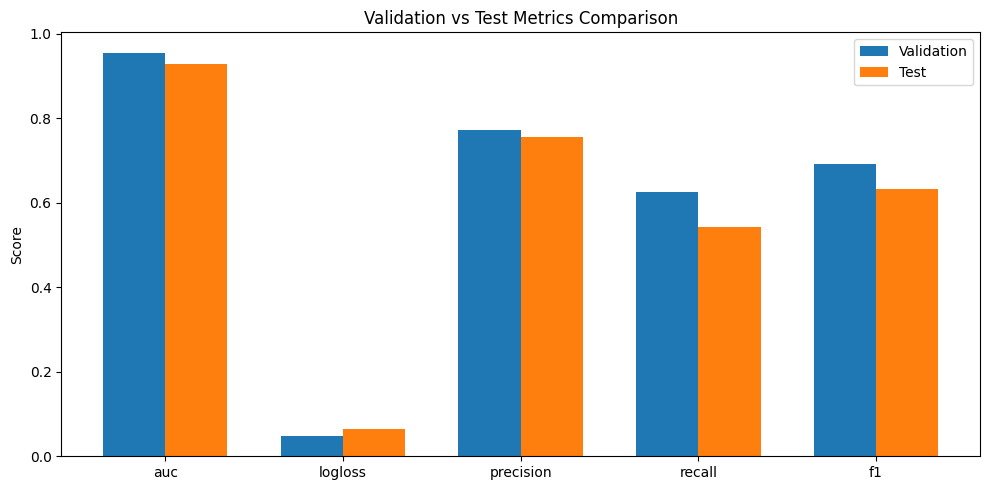

In [82]:
plot_val_test_scores(metrics_val_purch,metrics_test_purch)

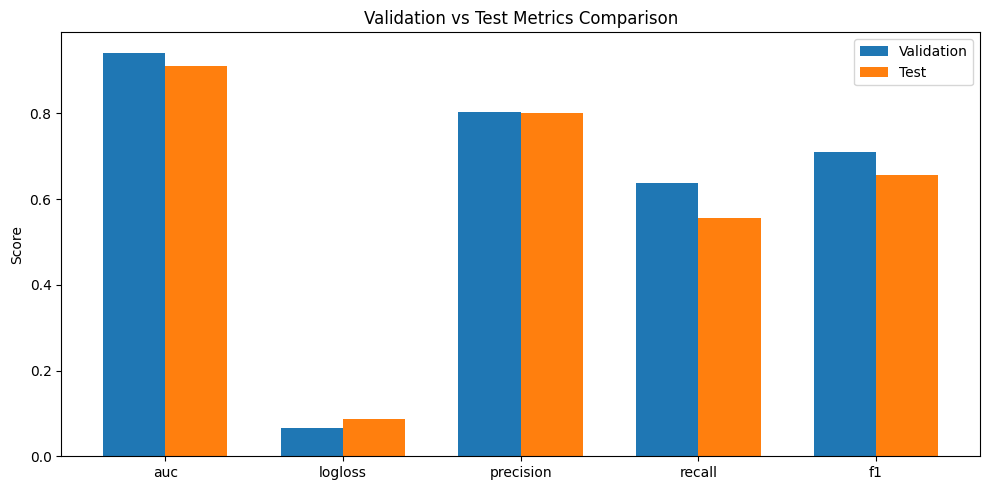

In [83]:
plot_val_test_scores(metrics_val_purch2,metrics_test_purch2)

In [69]:
metrics_val_purch

{'auc': 0.9556339142142501,
 'logloss': 0.04812702474957142,
 'precision': 0.7718687872763419,
 'recall': 0.6259572752922209,
 'f1': 0.6912975740040063,
 'confusion_matrix': [[177984, 918], [1856, 3106]]}

In [70]:
metrics_test_purch

{'auc': 0.9272931054034708,
 'logloss': 0.06522913571054569,
 'precision': 0.7555448408871746,
 'recall': 0.5430601282273436,
 'f1': 0.6319185401754209,
 'confusion_matrix': [[177079, 1014], [2637, 3134]]}

# Feature Importance

In [52]:
import pandas as pd

importance_df = pd.DataFrame({
    'feature': model_purch.feature_name(),
    'importance_gain': model_purch.feature_importance(importance_type='gain'),
    'importance_split': model_purch.feature_importance(importance_type='split')
})

importance_df = importance_df.sort_values('importance_gain', ascending=False)
importance_df.head(20)


,feature,importance_gain,importance_split
13,roll_purchased_4_past,795777.491566,41
16,customer_quantity_until_last_week,285280.096476,81
15,customer_purch_until_last_week,272901.783645,106
14,roll_quantity_4_past,167109.153864,66
4,customer_id,105352.389801,904
5,product_id,66693.899994,808
3,cust_age_days,46826.617428,601
0,week,43342.807537,625
17,purchased_with_others_last_week,19805.244201,29
1,month,13180.663091,193


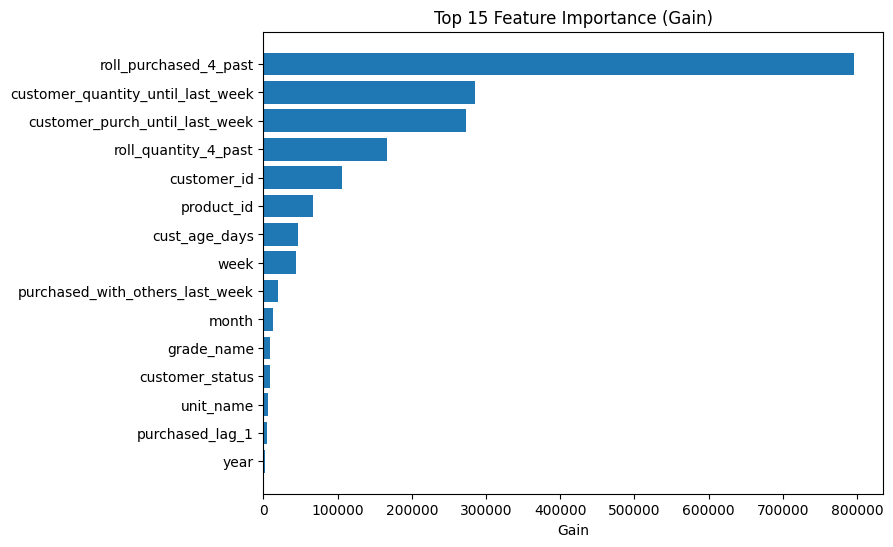

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df.head(15)['feature'],
    importance_df.head(15)['importance_gain']
)
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importance (Gain)')
plt.xlabel('Gain')
plt.show()


In [54]:
import pandas as pd

importance_df = pd.DataFrame({
    'feature': model_purch2.feature_name(),
    'importance_gain': model_purch2.feature_importance(importance_type='gain'),
    'importance_split': model_purch2.feature_importance(importance_type='split')
})

importance_df = importance_df.sort_values('importance_gain', ascending=False)
importance_df.head(20)


,feature,importance_gain,importance_split
14,roll_quantity_4_past,744542.322432,31
15,customer_purch_until_last_week,464231.678804,124
16,customer_quantity_until_last_week,333342.224882,49
13,roll_purchased_4_past,260533.165630,60
4,customer_id,181615.840740,996
5,product_id,119483.098919,919
0,week,52622.330799,540
3,cust_age_days,49300.030466,474
1,month,21130.884968,193
6,grade_name,15887.746801,148


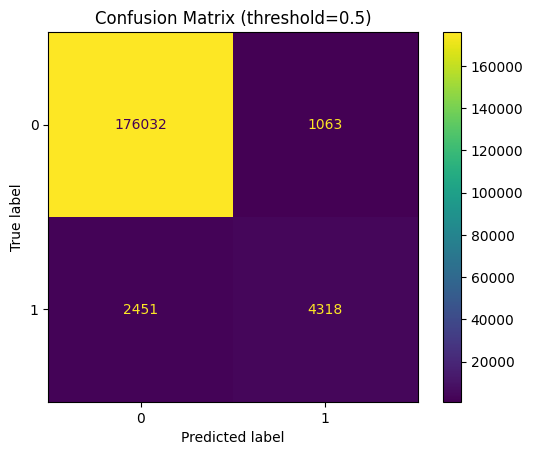

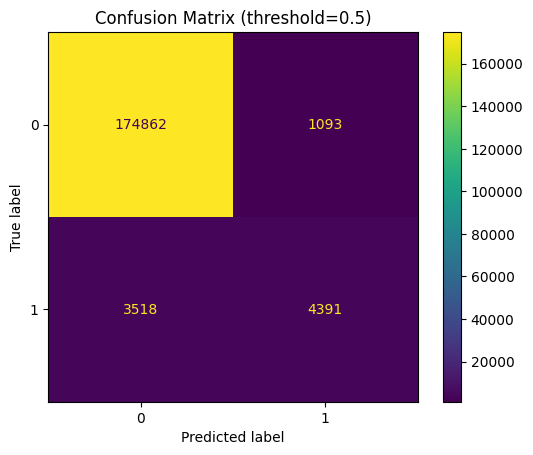

In [62]:
from sklearn import metrics

from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def compute_metrics(y_true,preds,threshold,plot_cm=True):
        out = {}

        out['auc'] = float(roc_auc_score(y_true, preds))
        out['logloss'] = float(log_loss(y_true, preds, labels=[0,1])) # labels: bu problemde mümkün olan sınıflar bunlar

        # binary predictions at 0.5
        y_pred_bin = (preds >= threshold).astype(int)

        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred_bin, average='binary', zero_division=0)

        out.update({'precision': float(p), 'recall': float(r), 'f1': float(f1)})
        # out['confusion_matrix'] = confusion_matrix(y_true, y_pred_bin).tolist()

        cm = confusion_matrix(y_true, y_pred_bin)
        out['confusion_matrix'] = cm.tolist()

        if plot_cm:
            disp = metrics.ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=[0, 1]
            )
            disp.plot()
            plt.title(f'Confusion Matrix (threshold={threshold})')
            plt.show()


        return out

metrics_val_purch = compute_metrics(y_val_purch, preds_val_purch,0.5,plot_cm=False)
metrics_test_purch = compute_metrics(y_test_purch, preds_test_purch,0.5,plot_cm=False)

metrics_val_purch2 = compute_metrics(y_val_purch2, preds_val_purch2,0.5,plot_cm=True)
metrics_test_purch2 = compute_metrics(y_test_purch2, preds_test_purch2,0.5,plot_cm=True)

In [60]:
metrics_val_purch2

{'auc': 0.9418414186863064,
 'logloss': 0.06572288605742263,
 'precision': 0.8024530756364988,
 'recall': 0.6379081105037672,
 'f1': 0.7107818930041152,
 'confusion_matrix': [[176032, 1063], [2451, 4318]]}

In [61]:
metrics_test_purch2

{'auc': 0.9105996501888676,
 'logloss': 0.08747254009965005,
 'precision': 0.800692924872356,
 'recall': 0.555190289543558,
 'f1': 0.6557156723661615,
 'confusion_matrix': [[174862, 1093], [3518, 4391]]}

In [57]:
metrics_val_purch

{'auc': 0.9556339142142501,
 'logloss': 0.04812702474957142,
 'precision': 0.7718687872763419,
 'recall': 0.6259572752922209,
 'f1': 0.6912975740040063,
 'confusion_matrix': [[177984, 918], [1856, 3106]]}

In [58]:
metrics_test_purch

{'auc': 0.9272931054034708,
 'logloss': 0.06522913571054569,
 'precision': 0.7555448408871746,
 'recall': 0.5430601282273436,
 'f1': 0.6319185401754209,
 'confusion_matrix': [[177079, 1014], [2637, 3134]]}

In [5]:
df_train_prepared.head(2)

,ID,customer_id,product_unit_variant_id,week_start,qty_this_week,num_orders_week,spend_this_week,purchased_this_week,product_id,grade_name,unit_name,product_grade_variant_id,selling_price,customer_category,customer_status,customer_created_at,Target_qty_next_1w,Target_purchase_next_1w,Target_qty_next_2w,Target_purchase_next_2w,week,month,year,cust_age_days,purchased_lag_1,purchased_lag_2,purchased_lag_3,roll_purchased_4_including_current,roll_purchased_4_past,roll_quantity_4_including_current,roll_quantity_4_past,customer_purch_until_last_week,customer_quantity_until_last_week,purchased_with_other_products,purchased_with_others_last_week
0,339_1_20241028,339,1,2024-10-28,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0,44,10,2024,395,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,339_1_20241104,339,1,2024-11-04,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0,45,11,2024,402,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [ ]:
# Iter 1  → val logloss = 0.48
# Iter 2  → val logloss = 0.42
# Iter 3  → val logloss = 0.40  ← en iyi
# Iter 4  → val logloss = 0.41
# Iter 5  → val logloss = 0.42
# Iter 6  → val logloss = 0.44  (50 tur iyileşme yok → STOP)


In [6]:
# --------------------------------------------------------------------------------------------
# product_unit_variant_id: product_id, grade_name, unit_name'in birleşiminden oluşuyordu
# onu almak yerine diğerlerini aldım.

categoric_variables = ['customer_id','product_id','grade_name','unit_name','customer_category','customer_status']

# --------------------------------------------------------------------------------------------

# categoric_variables içindekileri de buna dahil ettim.

features = [
    # time
    'week','month','year','cust_age_days',

    # categorical high-cardinality
    'customer_id','product_id',

    # categorical low-cardinality
    'grade_name','unit_name','customer_category','customer_status',

    # behavioral lags
    'purchased_lag_1','purchased_lag_2','purchased_lag_3',
    'roll_purchased_4_past','roll_quantity_4_past',
    'customer_purch_until_last_week','customer_quantity_until_last_week',
    'purchased_with_others_last_week'
]


In [18]:
df_train_prepared.head()

,ID,customer_id,product_unit_variant_id,week_start,qty_this_week,num_orders_week,spend_this_week,purchased_this_week,product_id,grade_name,unit_name,product_grade_variant_id,selling_price,customer_category,customer_status,customer_created_at,Target_qty_next_1w,Target_purchase_next_1w,Target_qty_next_2w,Target_purchase_next_2w,week,month,year,cust_age_days,purchased_lag_1,purchased_lag_2,purchased_lag_3,roll_purchased_4_including_current,roll_purchased_4_past,roll_quantity_4_including_current,roll_quantity_4_past,customer_purch_until_last_week,customer_quantity_until_last_week,purchased_with_other_products,purchased_with_others_last_week
0,339_1_20241028,339,1,2024-10-28,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0,44,10,2024,395,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,339_1_20241104,339,1,2024-11-04,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0,45,11,2024,402,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,339_1_20241111,339,1,2024-11-11,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0,46,11,2024,409,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,339_1_20241118,339,1,2024-11-18,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0,47,11,2024,416,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,339_1_20241125,339,1,2024-11-25,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0,48,11,2024,423,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [8]:
info_1w = train_val_test_lightgbm(
    df=df_train_prepared,
    features=features,
    target_col='Target_purchase_next_1w',
    val_weeks=4,
    test_weeks=4,
    categorical_features=categoric_variables,
    num_boost_round=2000,
    early_stopping_rounds=100,
    verbose=True
)


In [9]:
info_1w

{'n_train': 1746708,
 'n_val': 183864,
 'n_test': 183864,
 'model': <lightgbm.basic.Booster at 0x30314f4c0>,
 'metrics_val': {'auc': 0.9556339142142501,
  'logloss': 0.04812702474957142,
  'precision_0.5': 0.7718687872763419,
  'recall_0.5': 0.6259572752922209,
  'f1_0.5': 0.6912975740040063,
  'confusion_matrix_0.5': [[177984, 918], [1856, 3106]]},
 'metrics_test': {'auc': 0.9272931054034708,
  'logloss': 0.06522913571054569,
  'precision_0.5': 0.7555448408871746,
  'recall_0.5': 0.5430601282273436,
  'f1_0.5': 0.6319185401754209,
  'confusion_matrix_0.5': [[177079, 1014], [2637, 3134]]},
 'preds_val': array([0.00153202, 0.00606671, 0.00223339, ..., 0.00219677, 0.00957975,
        0.0019561 ], shape=(183864,)),
 'preds_test': array([0.00270091, 0.001305  , 0.00192091, ..., 0.00216674, 0.00983823,
        0.00104671], shape=(183864,)),
 'X_val':          week  month  year  cust_age_days customer_id product_id grade_name  \
 1838888    30      7  2025              0         721        1

In [24]:
info_qty_1w = train_val_test_lightgbm(
    df=df_train_prepared,
    features=features,
    target_col='Target_quantity_next_1w',
    val_weeks=4,
    test_weeks=4,
    categorical_features=categoric_variables,
    num_boost_round=2000,
    early_stopping_rounds=100,
    verbose=True,
    objective='regression'
)

TypeError: train_val_test_lightgbm() got an unexpected keyword argument 'objective'

In [23]:
info_1w['n_train']

1746708

In [ ]:
train_val_test_lightgbm(df, features, target_col,
                           val_weeks=4, test_weeks=4,
                           params=None, num_boost_round=1000,
                           early_stopping_rounds=50, verbose=False,
                           categorical_features=None)

In [ ]:
full_model_1w = train_val_test_lightgbm(train_df, features, 'Target_purchase_next_1w')
full_model_2w = train_val_test_lightgbm(train_df, features, 'Target_purchase_next_2w')


In [2]:
import pandas as pd

## <font color='pink'>Data Read <font>

In [ ]:
# Baseline pipeline: feature engineering + LightGBM temporal split training
# Gereksinimler: pandas, numpy, scikit-learn, lightgbm
# pip install pandas numpy scikit-learn lightgbm

import pandas as pd
import numpy as np
import warnings
from sklearn.metrics import roc_auc_score, log_loss
import lightgbm as lgb

###############################
# 1) Yardımcı / IO fonksiyonları
###############################
def load_train_csv(path):
    """
    CSV'yi oku ve tarih kolonlarını parse et.
    """
    df = pd.read_csv(path)
    # ensure expected columns exist
    df['week_start'] = pd.to_datetime(df['week_start'])
    if 'customer_created_at' in df.columns:
        df['customer_created_at'] = pd.to_datetime(df['customer_created_at'])
    else:
        # varsa doldurmak için makul bir tarih koy (eğer yoksa bazı features boş kalır)
        df['customer_created_at'] = df['week_start'] - pd.Timedelta(days=365)
    return df

###############################
# 2) Temel feature engineering (hızlı, baseline)
###############################
def basic_feature_engineering(df):
    """
    Minimal ve hızlı feature engineering:
      - time features (week, month, year)
      - customer age in days
      - simple lag features (purchased_this_week lags 1..3)
      - rolling 4-week sum grouped by (customer_id, product_unit_variant_id)
      - sku cumulative purchases up to previous week
      - simple encodings (customer_status)
    Returns: engineered_df, feature_list
    """
    df = df.copy()
    # sıralama (önemli)
    df = df.sort_values(['customer_id','product_unit_variant_id','week_start']).reset_index(drop=True)

    # time features
    df['week'] = df['week_start'].dt.isocalendar().week.astype(int)
    df['month'] = df['week_start'].dt.month.astype(int)
    df['year'] = df['week_start'].dt.year.astype(int)
    # customer age
    df['cust_age_days'] = (df['week_start'] - df['customer_created_at']).dt.days.clip(lower=0).fillna(0).astype(int)

    # groupby object
    grp = df.groupby(['customer_id','product_unit_variant_id'])['purchased_this_week']

    # lags (1..3)
    df['lag_1'] = grp.shift(1).fillna(0).astype(int)
    df['lag_2'] = grp.shift(2).fillna(0).astype(int)
    df['lag_3'] = grp.shift(3).fillna(0).astype(int)

    # rolling 4-week purchases (including current row -> but we'll shift to be strictly historical if we want)
    # here compute rolling over previous 4 rows including current and then subtract current to have "past 4 weeks"
    roll = grp.rolling(4, min_periods=1).sum().reset_index(level=[0,1], drop=True)
    df['roll_4_including_current'] = roll.fillna(0)
    # past 4 (exclude current)
    df['roll_4_past'] = (df['roll_4_including_current'] - df['purchased_this_week']).clip(lower=0)

    # sku cumulative purchases up to previous week (shifted cumsum)
    df['sku_cum_purch_all'] = df.groupby('product_unit_variant_id')['purchased_this_week'].cumsum().shift(1).fillna(0)

    # simple customer-level proxy: count of unique skus purchased so far (proxy via cumcount of unique appearance)
    # (This is a proxy; for true unique count we'd need more complex accumulation)
    df['cust_seen_rows'] = df.groupby('customer_id').cumcount()
    # encode customer_status
    if 'customer_status' in df.columns:
        df['customer_status_code'] = (df['customer_status']=='active').astype(int)
    else:
        df['customer_status_code'] = 1

    # price/qty features if exist: include lag for qty and spend too
    if 'qty_this_week' in df.columns:
        g_qty = df.groupby(['customer_id','product_unit_variant_id'])['qty_this_week']
        df['qty_lag_1'] = g_qty.shift(1).fillna(0)
    if 'spend_this_week' in df.columns:
        g_spend = df.groupby(['customer_id','product_unit_variant_id'])['spend_this_week']
        df['spend_lag_1'] = g_spend.shift(1).fillna(0)

    # final feature list (choose a compact set for baseline)
    features = [
        'week','month','year','cust_age_days',
        'lag_1','lag_2','lag_3',
        'roll_4_past','sku_cum_purch_all','cust_seen_rows',
        'customer_status_code'
    ]
    # add optional ones if available
    if 'qty_lag_1' in df.columns: features.append('qty_lag_1')
    if 'spend_lag_1' in df.columns: features.append('spend_lag_1')

    # fill any remaining NaNs (safety)
    df[features] = df[features].fillna(0)
    return df, features

###############################
# 3) Baseline LightGBM training (temporal split)
###############################
def train_lightgbm_temporal(df, features, target_col, val_weeks=4, params=None, verbose=False):
    """
    Temporal split training:
      - uses last `val_weeks` distinct week_start values as validation set
      - returns trained model and metrics on validation
    """
    df = df.copy().sort_values('week_start')
    unique_weeks = np.sort(df['week_start'].unique())
    if len(unique_weeks) < 2:
        raise ValueError("Not enough distinct weeks to do temporal split. Need >=2 distinct week_start values.")
    # determine cutoff
    if len(unique_weeks) > val_weeks:
        cutoff_week = unique_weeks[-val_weeks]
    else:
        cutoff_week = unique_weeks[-1]  # fallback -> small data case
        warnings.warn("Fewer distinct weeks than val_weeks; validation will be small or empty.")

    train_mask = df['week_start'] < cutoff_week
    val_mask = df['week_start'] >= cutoff_week

    X_train = df.loc[train_mask, features]
    y_train = df.loc[train_mask, target_col]
    X_val = df.loc[val_mask, features]
    y_val = df.loc[val_mask, target_col]

    if X_train.shape[0] < 50:
        warnings.warn(f"Training rows < 50 ({X_train.shape[0]}). Model will be unreliable on tiny datasets.")
    if X_val.shape[0] < 10:
        warnings.warn(f"Validation rows < 10 ({X_val.shape[0]}). Metrics may be noisy.")

    # default params
    if params is None:
        params = {
            'objective': 'binary',
            'metric': 'binary_logloss',
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'learning_rate': 0.05,
            'num_leaves': 63,
            'seed': 42
        }

    lgb_train = lgb.Dataset(X_train, label=y_train)
    lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

    model = lgb.train(params, lgb_train,
                      valid_sets=[lgb_train, lgb_val],
                      num_boost_round=1000,
                      early_stopping_rounds=50,
                      verbose_eval=100 if verbose else False)

    # predict on validation
    preds = model.predict(X_val, num_iteration=model.best_iteration)

    metrics = {}
    # compute AUC only if both classes present
    if len(np.unique(y_val)) > 1:
        metrics['auc'] = float(roc_auc_score(y_val, preds))
    else:
        metrics['auc'] = None
    try:
        metrics['logloss'] = float(log_loss(y_val, preds, labels=[0,1]))
    except Exception as e:
        metrics['logloss'] = None
        metrics['logloss_error'] = str(e)

    info = {
        'n_train': X_train.shape[0],
        'n_val': X_val.shape[0],
        'model': model,
        'metrics': metrics
    }
    return info

###############################
# 4) Kullanım: tüm pipeline
###############################
def run_baseline_pipeline(train_csv_path, val_weeks=4, verbose=False):
    """
    Tek fonksiyonla: yükle -> fe -> train iki model (1w & 2w) -> döndür.
    """
    df = load_train_csv(train_csv_path)
    df_fe, features = basic_feature_engineering(df)

    print("Engineered features:", features)
    print("Data shape:", df_fe.shape)
    print("Distinct weeks:", len(df_fe['week_start'].unique()))

    # Model for 1-week target
    print("\nTraining model for Target_purchase_next_1w ...")
    info_1w = train_lightgbm_temporal(df_fe, features, 'Target_purchase_next_1w', val_weeks=val_weeks, verbose=verbose)
    print("1w metrics:", info_1w['metrics'], " n_train:", info_1w['n_train'], " n_val:", info_1w['n_val'])

    # Model for 2-week target
    print("\nTraining model for Target_purchase_next_2w ...")
    info_2w = train_lightgbm_temporal(df_fe, features, 'Target_purchase_next_2w', val_weeks=val_weeks, verbose=verbose)
    print("2w metrics:", info_2w['metrics'], " n_train:", info_2w['n_train'], " n_val:", info_2w['n_val'])

    return {
        'df_fe': df_fe,
        'features': features,
        'model_1w': info_1w['model'],
        'metrics_1w': info_1w['metrics'],
        'model_2w': info_2w['model'],
        'metrics_2w': info_2w['metrics']
    }

###############################
# 5) Eğer doğrudan notebook içinde küçük örnekle denemek istersen:
###############################
if __name__ == "__main__":
    # örnek: localde 'train.csv' path ver
    # result = run_baseline_pipeline("train.csv", val_weeks=4, verbose=True)
    print("Script hazır. run_baseline_pipeline('path/to/train.csv') diyerek çalıştırın.")


In [156]:
df.head().to_dict()

{'ID': {0: '339_1_20241028',
  1: '679_498_20241028',
  2: '679_502_20241028',
  3: '409_576_20241028',
  4: '778_560_20241028'},
 'customer_id': {0: 339, 1: 679, 2: 679, 3: 409, 4: 778},
 'product_unit_variant_id': {0: 1, 1: 498, 2: 502, 3: 576, 4: 560},
 'week_start': {0: '2024-10-28',
  1: '2024-10-28',
  2: '2024-10-28',
  3: '2024-10-28',
  4: '2024-10-28'},
 'qty_this_week': {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0},
 'num_orders_week': {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0},
 'spend_this_week': {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0},
 'purchased_this_week': {0: 0, 1: 0, 2: 0, 3: 0, 4: 0},
 'product_id': {0: 65, 1: 430, 2: 434, 3: 484, 4: 341},
 'grade_name': {0: 'GRADE_01',
  1: 'GRADE_05',
  2: 'GRADE_05',
  3: 'GRADE_05',
  4: 'GRADE_01'},
 'unit_name': {0: 'UNIT_004',
  1: 'UNIT_004',
  2: 'UNIT_004',
  3: 'UNIT_006',
  4: 'UNIT_004'},
 'product_grade_variant_id': {0: 84, 1: 479, 2: 483, 3: 539, 4: 351},
 'selling_price': {0: 280.0, 1: 711.0, 2: 1047.0, 3: 6581.0, 4: 55.0}

In [132]:
df.sort_values(by=['customer_id','product_unit_variant_id','week_start'])

,ID,customer_id,product_unit_variant_id,week_start,qty_this_week,num_orders_week,spend_this_week,purchased_this_week,product_id,grade_name,unit_name,product_grade_variant_id,selling_price,customer_category,customer_status,customer_created_at,Target_qty_next_1w,Target_purchase_next_1w,Target_qty_next_2w,Target_purchase_next_2w
0,339_1_20241028,339,1,2024-10-28,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
89670,339_1_20241104,339,1,2024-11-04,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
130621,339_1_20241111,339,1,2024-11-11,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
180545,339_1_20241118,339,1,2024-11-18,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
195750,339_1_20241125,339,1,2024-11-25,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1914574,782_655_20250811,782,655,2025-08-11,0.0,0.0,0.0,0,394,GRADE_01,UNIT_004,442,150.0,CUST_CAT_003,CUST_STAT_000,2025-10-27,0.0,0,0.0,0
1974667,782_655_20250818,782,655,2025-08-18,0.0,0.0,0.0,0,394,GRADE_01,UNIT_004,442,150.0,CUST_CAT_003,CUST_STAT_000,2025-10-27,0.0,0,0.0,0
1986230,782_655_20250825,782,655,2025-08-25,0.0,0.0,0.0,0,394,GRADE_01,UNIT_004,442,150.0,CUST_CAT_003,CUST_STAT_000,2025-10-27,0.0,0,0.0,0
2026864,782_655_20250901,782,655,2025-09-01,0.0,0.0,0.0,0,394,GRADE_01,UNIT_004,442,150.0,CUST_CAT_003,CUST_STAT_000,2025-10-27,0.0,0,0.0,0


------

In [ ]:
# Higher-level product identifier

l_products = sorted(df['product_id'].unique())

In [110]:
l_products[:10]

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

----------

In [ ]:
# The selling unit for the product (SKU) (e.g. kg, bunch, pack).

l_unit_name = sorted(df['unit_name'].unique())

In [108]:
l_unit_name

['UNIT_000',
 'UNIT_001',
 'UNIT_002',
 'UNIT_003',
 'UNIT_004',
 'UNIT_005',
 'UNIT_006',
 'UNIT_007',
 'UNIT_008',
 'UNIT_009',
 'UNIT_010']

------

In [105]:
# A category label representing the customer segment (e.g. retailer, hotel, food service).

l_customer_segment = sorted(df['customer_category'].unique())

In [106]:
l_customer_segment

['CUST_CAT_000',
 'CUST_CAT_001',
 'CUST_CAT_002',
 'CUST_CAT_003',
 'CUST_CAT_004',
 'CUST_CAT_005',
 'CUST_CAT_006',
 'CUST_CAT_007']

In [135]:
df_likelihood = df[['ID','customer_id','product_unit_variant_id','week_start','purchased_this_week','Target_purchase_next_1w','Target_purchase_next_2w']]

In [138]:
df_likelihood.tail()

,ID,customer_id,product_unit_variant_id,week_start,purchased_this_week,Target_purchase_next_1w,Target_purchase_next_2w
2114431,587_29_20250908,587,29,2025-09-08,0,0,0
2114432,719_42_20250908,719,42,2025-09-08,0,0,0
2114433,433_271_20250908,433,271,2025-09-08,0,0,0
2114434,699_476_20250908,699,476,2025-09-08,0,0,0
2114435,589_213_20250908,589,213,2025-09-08,0,0,0


In [140]:
df_sample_customer = df_likelihood[df_likelihood['customer_id']==587]

In [146]:
df['week_start'].max()

'2025-09-08'

In [147]:
df.columns

Index(['ID', 'customer_id', 'product_unit_variant_id', 'week_start',
       'qty_this_week', 'num_orders_week', 'spend_this_week',
       'purchased_this_week', 'product_id', 'grade_name', 'unit_name',
       'product_grade_variant_id', 'selling_price', 'customer_category',
       'customer_status', 'customer_created_at', 'Target_qty_next_1w',
       'Target_purchase_next_1w', 'Target_qty_next_2w',
       'Target_purchase_next_2w'],
      dtype='object')

Text(0.5, 1.0, 'Customer 587 – SKU 5 Purchase History')

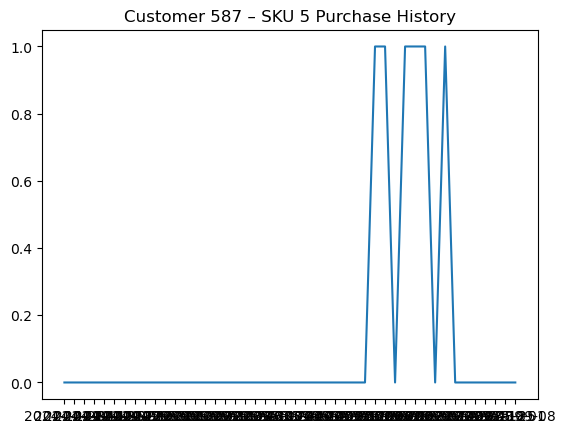

In [154]:
from matplotlib import pyplot as plt


tmp = df_sample_customer[(df_sample_customer['product_unit_variant_id'] == 5)].sort_values(by='week_start')

plt.plot(tmp['week_start'], tmp['purchased_this_week'])
plt.title("Customer 587 – SKU 5 Purchase History")

In [150]:
df_deneme.tail()

,ID,customer_id,product_unit_variant_id,week_start,purchased_this_week,Target_purchase_next_1w,Target_purchase_next_2w
1898088,587_5_20250811,587,5,2025-08-11,0,0,0
1936311,587_5_20250818,587,5,2025-08-18,0,0,0
2012529,587_5_20250825,587,5,2025-08-25,0,0,0
2060008,587_5_20250901,587,5,2025-09-01,0,0,0
2108236,587_5_20250908,587,5,2025-09-08,0,0,1


In [134]:
df[(df['customer_id'] == 339)]

,ID,customer_id,product_unit_variant_id,week_start,qty_this_week,num_orders_week,spend_this_week,purchased_this_week,product_id,grade_name,unit_name,product_grade_variant_id,selling_price,customer_category,customer_status,customer_created_at,Target_qty_next_1w,Target_purchase_next_1w,Target_qty_next_2w,Target_purchase_next_2w
0,339_1_20241028,339,1,2024-10-28,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
43848,339_185_20241028,339,185,2024-10-28,0.0,0.0,0.0,0,50,GRADE_01,UNIT_001,64,315.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
43863,339_62_20241028,339,62,2024-10-28,0.0,0.0,0.0,0,76,GRADE_01,UNIT_004,96,60.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
43866,339_604_20241028,339,604,2024-10-28,0.0,0.0,0.0,0,518,GRADE_01,UNIT_004,566,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
43868,339_56_20241028,339,56,2024-10-28,0.0,0.0,0.0,0,7,GRADE_01,UNIT_003,11,0.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2114150,339_163_20250908,339,163,2025-09-08,3.0,1.0,10256.0,1,123,GRADE_01,UNIT_004,160,310.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,2.0,1,7.0,1
2114155,339_321_20250908,339,321,2025-09-08,0.0,0.0,0.0,0,174,GRADE_01,UNIT_004,218,245.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
2114215,339_457_20250908,339,457,2025-09-08,0.0,0.0,0.0,0,335,GRADE_01,UNIT_004,344,140.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
2114245,339_3_20250908,339,3,2025-09-08,2.0,1.0,10256.0,1,84,GRADE_01,UNIT_004,105,210.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,3.0,1,5.0,1


In [115]:
df.head()

,ID,customer_id,product_unit_variant_id,week_start,qty_this_week,num_orders_week,spend_this_week,purchased_this_week,product_id,grade_name,unit_name,product_grade_variant_id,selling_price,customer_category,customer_status,customer_created_at,Target_qty_next_1w,Target_purchase_next_1w,Target_qty_next_2w,Target_purchase_next_2w
0,339_1_20241028,339,1,2024-10-28,0.0,0.0,0.0,0,65,GRADE_01,UNIT_004,84,280.0,CUST_CAT_003,CUST_STAT_000,2023-09-29,0.0,0,0.0,0
1,679_498_20241028,679,498,2024-10-28,0.0,0.0,0.0,0,430,GRADE_05,UNIT_004,479,711.0,CUST_CAT_003,CUST_STAT_000,2025-07-10,0.0,0,0.0,0
2,679_502_20241028,679,502,2024-10-28,0.0,0.0,0.0,0,434,GRADE_05,UNIT_004,483,1047.0,CUST_CAT_003,CUST_STAT_000,2025-07-10,0.0,0,0.0,0
3,409_576_20241028,409,576,2024-10-28,0.0,0.0,0.0,0,484,GRADE_05,UNIT_006,539,6581.0,CUST_CAT_003,CUST_STAT_000,2024-08-25,0.0,0,0.0,0
4,778_560_20241028,778,560,2024-10-28,0.0,0.0,0.0,0,341,GRADE_01,UNIT_004,351,55.0,CUST_CAT_003,CUST_STAT_000,2025-10-22,0.0,0,0.0,0


### <font color='white'>**Neyden kaç tane var?** <font>

- **product_unit_variant_id:** A unique identifier for a specific sellable product variant (e.g. a specific grade–unit combination).

- **customer_category**: A category label representing the customer segment (e.g. retailer, hotel, food service).

- **customer_status**: Operational status of the customer account (e.g. active, inactive)

- **unit_name**: The selling unit for the product (SKU) (e.g. kg, bunch, pack).

- **grade_name**: The grade of the product.

In [127]:
df[['grade_name','unit_name']].nunique()

grade_name     7
unit_name     11
dtype: int64

In [123]:
df[['product_id','product_unit_variant_id','product_grade_variant_id']].nunique()

product_id                  223
product_unit_variant_id     326
product_grade_variant_id    246
dtype: int64

In [125]:
df[['customer_id','customer_category','customer_status']].nunique()

customer_id          141
customer_category      8
customer_status        4
dtype: int64

### <font color='white'>**Aynı müşteri aynı ürünü farklı birimlerden alıyor mu? (Evet)** <font>

In [102]:
multi_unit_ids = df.groupby(['customer_id','product_id'])['unit_name'].nunique()

# aynı müşteri, ürün kombinasyonunda birden fazla unit_name'i olanlar

multi_unit_ids[multi_unit_ids>1].reset_index()['customer_id'].nunique()

141

### <font color='white'>**Bir müşteri üzerinden analiz** <font>

In [54]:
df.groupby('product_id')['unit_name'].unique().reset_index()


,product_id,unit_name
0,1,[UNIT_002]
1,2,[UNIT_004]
2,3,[UNIT_004]
3,4,"[UNIT_007, UNIT_004]"
4,5,[UNIT_008]
...,...,...
218,516,[UNIT_000]
219,518,[UNIT_004]
220,547,[UNIT_004]
221,548,[UNIT_004]


In [45]:
df[['product_id','grade_name','unit_name','product_unit_variant_id','product_grade_variant_id']].sort_values(by='product_id').reset_index(drop=True)

,product_id,grade_name,unit_name,product_unit_variant_id,product_grade_variant_id
0,1,GRADE_01,UNIT_002,171,1
1,1,GRADE_01,UNIT_002,171,1
2,1,GRADE_01,UNIT_002,171,1
3,1,GRADE_01,UNIT_002,171,1
4,1,GRADE_01,UNIT_002,171,1
...,...,...,...,...,...
2114431,568,GRADE_05,UNIT_010,653,615
2114432,568,GRADE_05,UNIT_010,653,615
2114433,568,GRADE_05,UNIT_010,653,615
2114434,568,GRADE_05,UNIT_010,653,615


In [34]:
df_train_raw.columns

Index(['ID', 'customer_id', 'product_unit_variant_id', 'week_start',
       'qty_this_week', 'num_orders_week', 'spend_this_week',
       'purchased_this_week', 'product_id', 'grade_name', 'unit_name',
       'product_grade_variant_id', 'selling_price', 'customer_category',
       'customer_status', 'customer_created_at', 'Target_qty_next_1w',
       'Target_purchase_next_1w', 'Target_qty_next_2w',
       'Target_purchase_next_2w'],
      dtype='object')

In [46]:
df[['customer_created_at','customer_id','customer_category','customer_status']].reset_index(drop=True)

,customer_created_at,customer_id,customer_category,customer_status
0,2023-09-29,339,CUST_CAT_003,CUST_STAT_000
1,2025-07-10,679,CUST_CAT_003,CUST_STAT_000
2,2025-07-10,679,CUST_CAT_003,CUST_STAT_000
3,2024-08-25,409,CUST_CAT_003,CUST_STAT_000
4,2025-10-22,778,CUST_CAT_003,CUST_STAT_000
...,...,...,...,...
2114431,2025-04-12,587,CUST_CAT_003,CUST_STAT_000
2114432,2025-08-27,719,CUST_CAT_003,CUST_STAT_000
2114433,2024-04-08,433,CUST_CAT_000,CUST_STAT_002
2114434,2025-08-11,699,CUST_CAT_003,CUST_STAT_000


In [48]:
# Operational status of the customer account (e.g. active, inactive).

l_customer_activation_status = sorted(df['customer_status'].unique())

In [25]:
sorted(set(df_train_raw['product_id']).tolist())

AttributeError: 'set' object has no attribute 'tolist'

In [ ]:
1. Müşteriler unique
2. Aldıkları ürünler unique
3. product_unit_variant_id aldıkları ürünlerin variantı
4. Müşteri, aldıkları ürünün variantı, aldıkları hafta

In [16]:
df_train_raw.groupby('product_id')['ID'].count()

product_id
1       6486
2      12972
3       6486
4      12972
5       6486
       ...  
516     6486
518     6486
547     6486
548     6486
568     6486
Name: ID, Length: 223, dtype: int64

In [6]:
df_train_raw['week_start'].unique()

array(['2024-10-28', '2024-11-04', '2024-11-11', '2024-11-18',
       '2024-11-25', '2024-12-02', '2024-12-09', '2024-12-16',
       '2024-12-23', '2024-12-30', '2025-01-06', '2025-01-13',
       '2025-01-20', '2025-01-27', '2025-02-03', '2025-02-10',
       '2025-02-17', '2025-02-24', '2025-03-03', '2025-03-10',
       '2025-03-17', '2025-03-24', '2025-03-31', '2025-04-07',
       '2025-04-14', '2025-04-21', '2025-04-28', '2025-05-05',
       '2025-05-12', '2025-05-19', '2025-05-26', '2025-06-02',
       '2025-06-09', '2025-06-16', '2025-06-23', '2025-06-30',
       '2025-07-07', '2025-07-14', '2025-07-21', '2025-07-28',
       '2025-08-04', '2025-08-11', '2025-08-18', '2025-08-25',
       '2025-09-01', '2025-09-08'], dtype=object)

## <font color='pink'>Data Analysis and Visualization <font>

In [9]:
df_train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2114436 entries, 0 to 2114435
Data columns (total 20 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   ID                        object 
 1   customer_id               int64  
 2   product_unit_variant_id   int64  
 3   week_start                object 
 4   qty_this_week             float64
 5   num_orders_week           float64
 6   spend_this_week           float64
 7   purchased_this_week       int64  
 8   product_id                int64  
 9   grade_name                object 
 10  unit_name                 object 
 11  product_grade_variant_id  int64  
 12  selling_price             float64
 13  customer_category         object 
 14  customer_status           object 
 15  customer_created_at       object 
 16  Target_qty_next_1w        float64
 17  Target_purchase_next_1w   int64  
 18  Target_qty_next_2w        float64
 19  Target_purchase_next_2w   int64  
dtypes: float64(6), int64(7),

<Axes: >

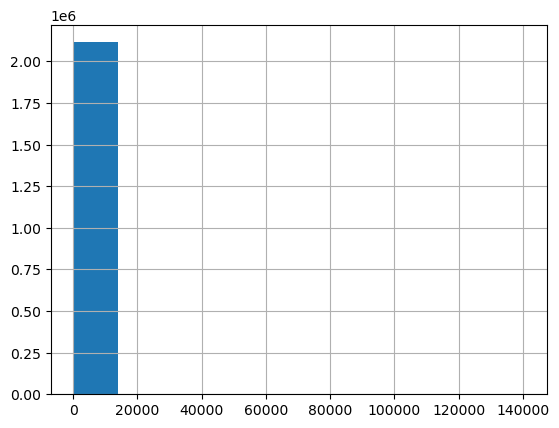

In [8]:
df_train_raw['qty_this_week'].hist()

In [5]:
df_train_raw.columns

Index(['ID', 'customer_id', 'product_unit_variant_id', 'week_start',
       'qty_this_week', 'num_orders_week', 'spend_this_week',
       'purchased_this_week', 'product_id', 'grade_name', 'unit_name',
       'product_grade_variant_id', 'selling_price', 'customer_category',
       'customer_status', 'customer_created_at', 'Target_qty_next_1w',
       'Target_purchase_next_1w', 'Target_qty_next_2w',
       'Target_purchase_next_2w'],
      dtype='object')